# Traitement de Données - Dossiers d'Assurance Assistance

## Objectif:

Ce notebook réalise le traitement complet des trois tables de données brutes :  
- `dossier.csv` : dossiers d'assistance automobile (2021-2022)  
- `temps.csv` : temps passé par chaque agent sur chaque dossier  
- `ressources.csv` : profil et présence des agents  

### Etapes du traitement

1. **Chargement et parsing** des CSV (gestion des guillemets, encodage)  
2. **Typage** des variables (numériques, dates, texte)  
3. **Analyse de completude** : valeurs manquantes, tokens spéciaux (???, NA)  
4. **Detection et traitement des doublons** (purs et impurs)  
5. **Controles de coherence** : dates, heures, croisements logiques  
6. **Imputation des valeurs manquantes** avec justification  
7. **Jointures** entre les 3 tables et feature engineering  
8. **Export** de la base finale prête pour la modélisation  

### Synthese des anomalies

Un **tableau recapitulatif** des anomalies détectées et des retraitements appliqués est presenté en fin de notebook.

---

# Imports des bibliothèques et configuration

In [1]:
# Import des bibliothèques

import numpy as np
import pandas as pd
import re
import os
from io import StringIO  
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16

# Affichage 
pd.set_option('display.max_columns', None)  # Toutes les colonnes visibles
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)  # Formatage flottants
sns.set_theme(style='whitegrid', context='notebook')    # Style seaborn   

In [2]:
# Chemins du projet
RAW_DIR  = '../data/raw'                           # Données sources brutes
OUT_DIR  = '../data/processed'                     # Donnees traitées
os.makedirs(OUT_DIR, exist_ok=True)                # Création du dossier si absent

# Fichiers de sortie
OUT_PATH       = os.path.join(OUT_DIR, 'base_model.csv')       # Base d'apprentissage
TEST_PATH      = os.path.join(OUT_DIR, 'base_test.csv')         # Base des dossiers test 
ANOMALIES_PATH = os.path.join(OUT_DIR, 'anomalies_retraitements.csv')  # Tableau récap

# Constantes metier (issues du glossaire)
CLE_DOSSIER        = 'Numero_dossier_ID'          # Clé primaire de dossier.csv
DATE_DEBUT_PERIODE = pd.Timestamp('2021-01-01')   # Début du périmètre
DATE_FIN_PERIODE   = pd.Timestamp('2022-12-31')   # Fin du périmètre
MATRICULE_AUTO     = 171                           # Matricule système (création automatique)
JOURNEE_THEORIQUE  = 7 + 20/60                     # 7h20 en heures (= 7.333...)
PLAFOND_DUREE_TRAV = 12.0                          # Plafond metier pour Duree.travail (h)

# Tokens considérés comme valeurs manquantes dans les CSV
# Issu de l'inspection des données : '???', 'NA', 'inconnu' et chaîne vide
TOKENS_MANQUANTS = {'NA', '???', 'inconnu', 'Inconnu', 'INCONNU', ''}

In [3]:
# Régistre d'anomalies : utilisé pour tracer tous les retraitements
# Chaque retraitement est poussé dans cette liste ; on en fera un tableau final.
ANOMALIES = []

def log_anomalie(table: str, etape: str, variable: str, n: int,
                 description: str, retraitement: str, justification: str) -> None:
    """Enregistre une anomalie et le retraitement applique.

    Parametres
    ----------
    table         : 'dossier' | 'temps' | 'ressources' | 'global'
    etape         : nom de l'etape (typage, doublons, NA, ...)
    variable      : colonne concernee (ou '-' si transversal)
    n             : nombre de lignes impactees
    description   : ce qu'on a observe
    retraitement  : action appliquee
    justification : pourquoi (règle métier / glossaire / bon sens)
    """
    ANOMALIES.append({
        'table': table, 'etape': etape, 'variable': variable,
        'lignes_impactees': n, 'description': description,
        'retraitement': retraitement, 'justification': justification,
    })

# 1. Table `dossier.csv`

**Grain** : 1 ligne = 1 dossier d'assistance.
**Rôle métier** : porte toutes les caracteristiques descriptives du dossier
(client, formule, cause, dates, services TOP., ...).
**Clé primaire** : `Numero_dossier_ID`.

## 1.1 Lecture

Le fichier `dossier.csv` est **non standard RFC 4180** :
- encodage **latin-1** (accents francais),
- chaque ligne entiere est entre guillemets, et chaque champ string l'est aussi
  (double-quoting imbrique du type `"...,""C5"",""F99"",..."`).

Une lecture naive avec `pd.read_csv` echoue. On pre-traite donc ligne par ligne :
on retire les guillemets externes et on remplace `""` par `"`, puis on passe
le resultat a `pandas` via un `StringIO`.


In [4]:
def load_dossier(path: str) -> pd.DataFrame:
    """Lit dossier.csv en corrigeant le double-quoting non standard."""
    # 1) Lecture brute en latin-1 (accents FR)
    with open(path, 'r', encoding='latin-1') as f:
        lignes = f.readlines()

    # 2) Nettoyage ligne par ligne
    lignes_nettoyees = []
    for ligne in lignes:
        ligne = ligne.rstrip('\n').rstrip('\r')          # Retirer fin de ligne
        if ligne.startswith('"') and ligne.endswith('"'):
            ligne = ligne[1:-1]                              # Retirer guillemets externes
        ligne = ligne.replace('""', '"')                  # Doubles guillemets -> simple
        lignes_nettoyees.append(ligne)

    # 3) Relecture via StringIO comme un vrai CSV standard
    csv_text = '\n'.join(lignes_nettoyees)
    return pd.read_csv(StringIO(csv_text))


# Chargement 
df_dossier_raw = load_dossier(os.path.join(RAW_DIR, 'dossier.csv'))
print(f"Dimensions brutes dossier.csv : {df_dossier_raw.shape}")
df_dossier_raw.head()

Dimensions brutes dossier.csv : (101234, 17)


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,Assistance.ou.Administratif,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties
0,7494402,C5,F99,2021/02/11,10:38:00,326,Panne mécanique,2021/02/11,Diesel,MCS,Assistance,1,0,0,0,0,0
1,7569082,C4,F14,2022/07/12,18:40:00,1164,Panne mécanique,2022/07/12,Essence,MCS,???,1,0,0,0,0,0
2,8111190,C0,F1,2021/01/08,12:32:00,1337,Panne mécanique,2021/01/08,Essence,MCS,Assistance,1,1,0,0,0,0
3,5630809,C7,F72,2021/11/08,19:46:00,1322,Panne mécanique,2021/11/08,Essence,MCS,Assistance,1,0,0,0,0,0
4,8179409,C4,F4,2021/08/11,18:12:00,2306,Panne mécanique,2021/08/11,Essence,Higgins,???,1,0,0,0,0,0


## 1.2 Info

In [5]:
# Dimensions, types, apercu
print("--- INFO ---")
df_dossier_raw.info()

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101234 entries, 0 to 101233
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   Numero_dossier_ID            101234 non-null  int64 
 1   Client                       101234 non-null  object
 2   Formule                      100285 non-null  object
 3   date.ouverture               101234 non-null  object
 4   heure.ouverture              101234 non-null  object
 5   Matricule.de.traitement      101234 non-null  int64 
 6   Cause.intervention           100234 non-null  object
 7   date.de.survenance           101234 non-null  object
 8   Type.d.energie               100240 non-null  object
 9   Outil.d.assistance           101234 non-null  object
 10  Assistance.ou.Administratif  101234 non-null  object
 11  TOP.D.R                      101234 non-null  int64 
 12  TOP.VR                       101234 non-null  int64 
 13  T

In [6]:
# Statistiques descriptives sur les colonnes numeriques
df_dossier_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Numero_dossier_ID,101234.0000,NaN,NaN,NaN,7003855.4117,885965.0453,5465153.0000,6238155.0000,7002116.5000,7771972.7500,8535999.0000
Client,101234,69,C4,30280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Formule,100285,364,F4,17192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date.ouverture,101234,731,2022/12/12,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heure.ouverture,101234,1437,25:00:00,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Matricule.de.traitement,101234.0000,NaN,NaN,NaN,935.9988,572.7015,123.0000,444.0000,866.0000,1362.0000,2549.0000
Cause.intervention,100234,7,Panne mécanique,68264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date.de.survenance,101234,773,2023,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type.d.energie,100240,7,Diesel,54610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outil.d.assistance,101234,2,MCS,77863,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Modalites des colonnes categorielles (aide a reperer les tokens manquants)
cols_cat_dossier = ['Client', 'Formule', 'Cause.intervention', 'Type.d.energie',
                    'Outil.d.assistance', 'Assistance.ou.Administratif']
for c in cols_cat_dossier:
    if c in df_dossier_raw.columns:
        modalites = df_dossier_raw[c].value_counts(dropna=False).head(15)
        print(f"--- {c} ({df_dossier_raw[c].nunique(dropna=False)} modalites) ---")
        print(modalites)
        print()

--- Client (69 modalites) ---
Client
C4     30280
C1     22546
C3     16605
C7      5574
C10     5291
C8      3742
C0      2469
C5      2176
C9      1279
C11     1223
C16     1133
C6      1081
C18     1007
C23      996
C14      975
Name: count, dtype: int64

--- Formule (365 modalites) ---
Formule
F4     17192
F6      7550
F8      5707
F0      5565
???     5000
F1      4471
F5      3806
F3      3573
F27     3466
F23     3298
F17     3235
F10     2932
F12     2339
F18     1889
F32     1654
Name: count, dtype: int64

--- Cause.intervention (8 modalites) ---
Cause.intervention
Panne mécanique               68264
Accident                      16034
Clés, Carburant, Crevaison    11684
Vol / Vandalisme               2260
Autres                         1471
NaN                            1000
Incendie                        405
Bris de glace                   116
Name: count, dtype: int64

--- Type.d.energie (8 modalites) ---
Type.d.energie
Diesel         54610
Essence        35908
Autre     

In [8]:
df_dossier = df_dossier_raw.copy()                 # On travaille sur une copie

# Typage des dates (format AAAA/MM/JJ explicitement indiqué dans le glossaire)
for col in ['date.ouverture', 'date.de.survenance']:
    avant_na = df_dossier[col].isna().sum()
    df_dossier[col] = pd.to_datetime(df_dossier[col],
                                     format='%Y/%m/%d',
                                     errors='coerce')  # Les formats exotiques deviennent NaT
    apres_na = df_dossier[col].isna().sum()
    n_rejet = apres_na - avant_na
    if n_rejet > 0:
        log_anomalie(
            table='dossier', etape='typage', variable=col, n=int(n_rejet),
            description=f"{n_rejet} valeurs non parseables au format AAAA/MM/JJ",
            retraitement='Converties en NaT',
            justification='Format impose par le glossaire ; valeurs hors format non fiables',
        )

# Typage des TOP.* en int8 (plus compact que int64)
cols_top = [c for c in df_dossier.columns if c.startswith('TOP.')]
df_dossier[cols_top] = df_dossier[cols_top].fillna(0).astype('int8')


print("Types apres typage :")
df_dossier.dtypes

Types apres typage :


Numero_dossier_ID                       int64
Client                                 object
Formule                                object
date.ouverture                 datetime64[ns]
heure.ouverture                        object
Matricule.de.traitement                 int64
Cause.intervention                     object
date.de.survenance             datetime64[ns]
Type.d.energie                         object
Outil.d.assistance                     object
Assistance.ou.Administratif            object
TOP.D.R                                  int8
TOP.VR                                   int8
TOP.Rappat.valide                        int8
TOP.Poursuite                            int8
TOP.Recup                                int8
TOP.Autres.Garanties                     int8
dtype: object

## 1.3 Vérification de la délimitation temporelle

Le glossaire impose un périmètre **France, dossiers ouverts en 2021-2022**.
On vérifie que `date.ouverture` tombe dans cette fenêtre et on **écarte les dossiers hors période**
(ils ne font pas partie du périmètre d'étude).

In [9]:
# Diagnostic avant filtre
print("Distribution par annee AVANT filtrage :")
print(df_dossier['date.ouverture'].dt.year.value_counts(dropna=False).sort_index())

# Filtrage 2021-2022
masque_periode = df_dossier['date.ouverture'].between(DATE_DEBUT_PERIODE, DATE_FIN_PERIODE)
n_hors = int((~masque_periode).sum())

if n_hors > 0:
    log_anomalie(
        table='dossier', etape='periode', variable='date.ouverture', n=n_hors,
        description=f"{n_hors} dossiers avec date.ouverture hors 2021-2022",
        retraitement='Lignes supprimees',
        justification="Glossaire : perimetre d'etude = dossiers 2021-2022 France",
    )

df_dossier = df_dossier.loc[masque_periode].copy()
print(f"\nDimensions apres filtrage : {df_dossier.shape}")

Distribution par annee AVANT filtrage :
date.ouverture
2021.0000    48212
2022.0000    53012
NaN             10
Name: count, dtype: int64

Dimensions apres filtrage : (101224, 17)


## 1.4 Retraitement des variables mal encodées

On **normalise les tokens manquants** `'???'`, `'NA'`, `'inconnu'`, `''` en vrais `NaN`
pour que pandas puisse les compter et les traiter uniformément.

*Justification* : lors de l'inspection des modalités (étape 1.2), on observe ces tokens
dans plusieurs colonnes catégorielles. Les laisser masque la réalité des valeurs manquantes
et fausse les agrégations qui suivront.

In [10]:
def normaliser_tokens_manquants(df: pd.DataFrame, cols: list, nom_table: str) -> pd.DataFrame:
    """Remplace les tokens '???', 'NA', 'inconnu', '' par NaN dans les colonnes cibles."""
    for c in cols:
        if c not in df.columns:
            continue
        serie = df[c].astype('string').str.strip()                  # Normalisation
        masque_token = serie.isin(TOKENS_MANQUANTS)                  # Quels sont les tokens ?
        n_touches = int(masque_token.sum())
        if n_touches > 0:
            df.loc[masque_token, c] = np.nan                          # -> NaN
            log_anomalie(
                table=nom_table, etape='encodage', variable=c, n=n_touches,
                description=f"{n_touches} valeurs parmi {sorted(TOKENS_MANQUANTS)}",
                retraitement="Remplacees par NaN",
                justification='Tokens d\'absence detectes par inspection visuelle',
            )
    return df


cols_normaliser = ['Client', 'Formule', 'Cause.intervention', 'Type.d.energie',
                   'Outil.d.assistance', 'Assistance.ou.Administratif']
df_dossier = normaliser_tokens_manquants(df_dossier, cols_normaliser, 'dossier')

# Verification
df_dossier[cols_normaliser].isna().sum()

Client                            0
Formule                        5949
Cause.intervention             1000
Type.d.energie                 1494
Outil.d.assistance                0
Assistance.ou.Administratif    9999
dtype: int64

## 1.5 Détection et résolution des doublons

On distingue **deux types de doublons** :

1. **Doublons purs** — lignes strictement identiques sur toutes les colonnes.
   → On en garde une seule (`drop_duplicates`).
2. **Doublons impurs** — mêmes `Numero_dossier_ID` mais divergence sur au moins une colonne.
   → Arbitrage **colonne par colonne** avec des règles métier (logique NB2).

### Règles d'arbitrage 

| Variable                         | Règle appliquée |
|----------------------------------|-----------------|
| `Formule`                        | Garder la première valeur non-manquante (ignorer `???`, `NA`) |
| `date.de.survenance`             | Garder la date complète `AAAA/MM/JJ` valide ; rejeter une année seule (`2023`) |
| `heure.ouverture`                | Garder l'heure valide `HH:MM:SS` ; rejeter `25:00:00`,|
| `Cause.intervention`, `Type.d.energie`, `Assistance.ou.Administratif` | Modalité la plus fréquente hors tokens manquants |
| Autres colonnes catégorielles    | Modalité la plus fréquente  |

La ligne de référence conservée pour chaque `Numero_dossier_ID` est celle qui a
**le plus de valeurs non-manquantes** (elle porte le plus d'information).


In [11]:
# Diagnostic
doublons_cle    = df_dossier[df_dossier.duplicated(subset=CLE_DOSSIER, keep=False)]
doublons_purs   = df_dossier[df_dossier.duplicated(keep=False)]
doublons_impurs = doublons_cle.drop(index=doublons_purs.index)

print(f"Doublons sur la cle    : {len(doublons_cle):>5}")
print(f"  dont purs            : {len(doublons_purs):>5}")
print(f"  dont impurs          : {len(doublons_impurs):>5}")

# Colonnes incoherentes parmi les doublons impurs
if len(doublons_impurs) > 0:
    nb_val_distinctes = (
        doublons_impurs.fillna('NA').groupby(CLE_DOSSIER).nunique().max()
    )
    cols_incoherentes = nb_val_distinctes[nb_val_distinctes > 1].index.tolist()
    print(f"\nColonnes incoherentes sur impurs : {cols_incoherentes}")
else:
    cols_incoherentes = []

Doublons sur la cle    :  2466
  dont purs            :  1684
  dont impurs          :   782

Colonnes incoherentes sur impurs : ['Formule', 'heure.ouverture', 'Cause.intervention', 'date.de.survenance', 'Type.d.energie', 'Assistance.ou.Administratif']


In [12]:
# Régles d'arbitrage colonne par colonne 

def _is_missing(x) -> bool:
    """Un token manquant ou NaN est-il present ?"""
    if pd.isna(x):
        return True
    return str(x).strip() in TOKENS_MANQUANTS


def _clean_str(x):
    """Nettoie une string, renvoie None si c'est un token manquant."""
    if _is_missing(x):
        return None
    return str(x).strip()


def choose_formule(s: pd.Series):
    """Formule : 1re valeur non manquante."""
    vals = s.dropna().astype(str).str.strip()
    good = vals[~vals.isin(TOKENS_MANQUANTS)]
    if len(good):
        return good.iloc[0], "Formule: garder 1re valeur non-manquante"
    return np.nan, "Formule: toutes valeurs manquantes"


def choose_categorie_mode(s: pd.Series, label: str):
    """Categorielle : modalite la plus frequente hors tokens manquants."""
    vals = s.dropna().astype(str).str.strip()
    vals = vals[~vals.isin(TOKENS_MANQUANTS)]
    if vals.empty:
        return np.nan, f"{label}: tout manquant"
    return vals.value_counts().index[0], f"{label}: modalite la plus frequente (hors tokens)"


def parse_date_stricte(x):
    """Parse AAAA/MM/JJ ; rejette une annee seule (ex: '2023')."""
    cx = _clean_str(x)
    if cx is None:
        return pd.NaT
    if re.fullmatch(r"\d{4}", cx):                            # Annee seule : rejet
        return pd.NaT
    dt = pd.to_datetime(cx, errors='coerce', format='%Y/%m/%d')
    if pd.isna(dt):
        dt = pd.to_datetime(cx, errors='coerce')               # Fallback tolerant
    return dt


def choose_date_survenance(s: pd.Series):
    """Date survenance : date complete valide la plus frequente."""
    parsed = s.map(parse_date_stricte).dropna()
    if parsed.empty:
        return np.nan, "date.de.survenance: aucune date complete valide"
    chosen = parsed.value_counts().index[0]
    return chosen.strftime('%Y/%m/%d'), "date.de.survenance: date complete valide (rejet annee seule)"


def parse_heure_stricte(x):
    """Valide HH:MM:SS strictement ; rejette 25:00:00 et consorts."""
    cx = _clean_str(x)
    if cx is None:
        return pd.NaT
    if not re.fullmatch(r"\d{2}:\d{2}:\d{2}", cx):
        return pd.NaT
    h, m, sec = map(int, cx.split(':'))
    if m > 59 or sec > 59 or h > 24:
        return pd.NaT
    if h == 24 and (m != 0 or sec != 0):                        # 24:00:00 toléré, 24:00:01 non
        return pd.NaT
    return pd.to_timedelta(cx)


def choose_heure_ouverture(s: pd.Series):
    """heure.ouverture : heure valide la plus frequente."""
    parsed = s.map(parse_heure_stricte).dropna()
    if parsed.empty:
        return np.nan, "heure.ouverture: aucune heure valide"
    chosen = parsed.value_counts().index[0]
    total = int(chosen.total_seconds())
    h, rem = divmod(total, 3600)
    m, sec = divmod(rem, 60)
    return f"{h:02d}:{m:02d}:{sec:02d}", "heure.ouverture: heure valide (rejet 25:00:00)"


def choose_best(col_name: str, series: pd.Series):
    """Dispatcher de regles."""
    if col_name == 'Formule':
        return choose_formule(series)
    if col_name == 'heure.ouverture':
        return choose_heure_ouverture(series)
    if col_name == 'date.de.survenance':
        return choose_date_survenance(series)
    if col_name in ['Cause.intervention', 'Type.d.energie', 'Assistance.ou.Administratif']:
        return choose_categorie_mode(series, col_name)
    return choose_categorie_mode(series, col_name)


In [13]:
# Application des régles aux doublons impurs

if len(doublons_impurs) > 0 and cols_incoherentes:

    ids_impurs = doublons_impurs[CLE_DOSSIER].unique()

    # 1) Ligne de reference = celle qui a le plus d'infos non manquantes
    tmp = doublons_impurs.copy()
    tmp['_nb_non_null'] = tmp.replace(list(TOKENS_MANQUANTS), np.nan).notna().sum(axis=1)
    ref_rows = (
        tmp.sort_values([CLE_DOSSIER, '_nb_non_null'], ascending=[True, False])
           .drop_duplicates(subset=CLE_DOSSIER, keep='first')
           .drop(columns=['_nb_non_null'])
    )

    # 2) Ecraser colonne par colonne avec la valeur retenue
    agg_rows = ref_rows.set_index(CLE_DOSSIER).copy()
    for col in cols_incoherentes:
        chosen_map = (
            doublons_impurs.groupby(CLE_DOSSIER)[col]
                           .apply(lambda s: choose_best(col, s)[0])
        )
        agg_rows[col] = chosen_map
    agg_rows = agg_rows.reset_index()

    # 3) Reconstruction : base sans les impurs + agg_rows
    base_sans_impurs = df_dossier[~df_dossier[CLE_DOSSIER].isin(ids_impurs)].copy()
    df_dossier = pd.concat([base_sans_impurs, agg_rows], ignore_index=True)

    log_anomalie(
        table='dossier', etape='doublons', variable=CLE_DOSSIER,
        n=int(len(doublons_impurs)),
        description=f"{len(doublons_impurs)} lignes impures reparties sur {len(ids_impurs)} dossiers",
        retraitement='Ligne de reference + arbitrage colonne par colonne (regles NB2)',
        justification='Impossible de supprimer car meme Numero_dossier_ID : reconciliation valeurs',
    )

# 4) Supprimer les doublons purs residuels (y compris ceux non touches par impurs)
n_avant = len(df_dossier)
df_dossier = df_dossier.drop_duplicates().drop_duplicates(subset=CLE_DOSSIER, keep='first')
n_supprimes = n_avant - len(df_dossier)
if n_supprimes > 0:
    log_anomalie(
        table='dossier', etape='doublons', variable=CLE_DOSSIER, n=int(n_supprimes),
        description=f"{n_supprimes} doublons purs",
        retraitement='drop_duplicates (garder 1 occurrence)',
        justification='Lignes strictement identiques : aucune perte d\'information',
    )

print(f"Dimensions apres deduplication : {df_dossier.shape}")
print(f"Cle unique ? : {df_dossier[CLE_DOSSIER].is_unique}")

Dimensions apres deduplication : (99991, 17)
Cle unique ? : True


## 1.6 Valeurs manquantes, détection et imputation

Pour chaque colonne avec NaN, on choisit une stratégie **justifiée métier** :

| Variable                    | Stratégie                | Justification |
|-----------------------------|--------------------------|---------------|
| `Formule`                   | Mode par `Client`        | La formule dépend du contrat client → le mode client est le meilleur proxy |
| `Cause.intervention`        | `'Non renseignée'`       | Rareté et surtout absence de proxy fiable : créer une modalité dédiée |
| `Type.d.energie`            | `'Non renseigné'`        | Champ explicitement **non obligatoire** selon le glossaire |
| `Assistance.ou.Administratif` | Mode global             | Binaire ; mode représente >80% des cas |
| `date.de.survenance`        | `date.ouverture`         | Cohérence métier : survenance ≤ ouverture (bornée inférieurement) |


In [14]:
# Diagnostic missing
print("--- Valeurs manquantes avant imputation ---")
print(df_dossier.isna().sum()[df_dossier.isna().sum() > 0])

--- Valeurs manquantes avant imputation ---
Formule                        5812
Cause.intervention              977
date.de.survenance              981
Type.d.energie                 1463
Assistance.ou.Administratif    9764
dtype: int64


In [15]:
# Formule : mode par Client
if df_dossier['Formule'].isna().any():
    n_na = int(df_dossier['Formule'].isna().sum())
    mode_par_client = df_dossier.groupby('Client')['Formule'].transform(
        lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
    )
    df_dossier['Formule'] = df_dossier['Formule'].fillna(mode_par_client)
    # Fallback mode global si certains clients n'ont que des NA
    df_dossier['Formule'] = df_dossier['Formule'].fillna(df_dossier['Formule'].mode().iloc[0])
    log_anomalie('dossier', 'missing', 'Formule', n_na,
                 f"{n_na} NaN", 'Impute par le mode de Formule par Client',
                 'Formule liee au contrat client')

# Cause.intervention : modalite dediee
if df_dossier['Cause.intervention'].isna().any():
    n_na = int(df_dossier['Cause.intervention'].isna().sum())
    df_dossier['Cause.intervention'] = df_dossier['Cause.intervention'].fillna('Non renseignee')
    log_anomalie('dossier', 'missing', 'Cause.intervention', n_na,
                 f"{n_na} NaN", "Impute 'Non renseignee'",
                 "Pas de proxy fiable : creer une modalite explicite")

# Type.d.energie : modalite dediee (champ non obligatoire)
if df_dossier['Type.d.energie'].isna().any():
    n_na = int(df_dossier['Type.d.energie'].isna().sum())
    df_dossier['Type.d.energie'] = df_dossier['Type.d.energie'].fillna('Non renseigne')
    log_anomalie('dossier', 'missing', 'Type.d.energie', n_na,
                 f"{n_na} NaN", "Impute 'Non renseigne'",
                 'Champ non obligatoire selon glossaire')

# Assistance.ou.Administratif : mode global
if df_dossier['Assistance.ou.Administratif'].isna().any():
    n_na = int(df_dossier['Assistance.ou.Administratif'].isna().sum())
    mode_val = df_dossier['Assistance.ou.Administratif'].mode().iloc[0]
    df_dossier['Assistance.ou.Administratif'] = df_dossier['Assistance.ou.Administratif'].fillna(mode_val)
    log_anomalie('dossier', 'missing', 'Assistance.ou.Administratif', n_na,
                 f"{n_na} NaN", f"Impute par mode global ('{mode_val}')",
                 'Binaire, mode >80%')

# Outil.d.assistance : mode global
if df_dossier['Outil.d.assistance'].isna().any():
    n_na = int(df_dossier['Outil.d.assistance'].isna().sum())
    mode_val = df_dossier['Outil.d.assistance'].mode().iloc[0]
    df_dossier['Outil.d.assistance'] = df_dossier['Outil.d.assistance'].fillna(mode_val)
    log_anomalie('dossier', 'missing', 'Outil.d.assistance', n_na,
                 f"{n_na} NaN", f"Impute par mode global ('{mode_val}')",
                 '2 modalites (MCS / Higgins)')

# date.de.survenance : on la traite dans la section incoherences (meilleur placement)
print("--- Valeurs manquantes apres imputation (hors date.de.survenance) ---")
print(df_dossier.isna().sum()[df_dossier.isna().sum() > 0])

--- Valeurs manquantes apres imputation (hors date.de.survenance) ---
date.de.survenance    981
dtype: int64


## 1.7 Incohérences métier

### Règle : `date.de.survenance ≤ date.ouverture`

Un sinistre ne peut pas survenir **après** l'ouverture du dossier.
Pour les violations (ou les NaT restants sur `date.de.survenance`), on impute par
`date.ouverture` : c'est la borne inférieure métier la plus raisonnable (un dossier ouvert
le jour J correspond au plus tard à un incident du jour J).

In [16]:
df_dossier.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99991 entries, 0 to 100832
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Numero_dossier_ID            99991 non-null  int64         
 1   Client                       99991 non-null  object        
 2   Formule                      99991 non-null  object        
 3   date.ouverture               99991 non-null  datetime64[ns]
 4   heure.ouverture              99991 non-null  object        
 5   Matricule.de.traitement      99991 non-null  int64         
 6   Cause.intervention           99991 non-null  object        
 7   date.de.survenance           99010 non-null  object        
 8   Type.d.energie               99991 non-null  object        
 9   Outil.d.assistance           99991 non-null  object        
 10  Assistance.ou.Administratif  99991 non-null  object        
 11  TOP.D.R                      99991 non-null  

In [17]:
# Re-typage des dates : après la résolution des doublons impurs (section 1.5),
# la fonction choose_date_survenance() retourne une string '%Y/%m/%d', ce qui
# melange Timestamp et str dans la colonne. On re-parse pour garantir un dtype
# datetime64 homogène avant toute comparaison.

for col in ['date.ouverture', 'date.de.survenance']:
    if df_dossier[col].dtype == object:
        df_dossier[col] = pd.to_datetime(df_dossier[col], errors='coerce')

# 1) NaT residuels sur date.de.survenance
masque_surv_na = df_dossier['date.de.survenance'].isna()
n_na_surv = int(masque_surv_na.sum())

# 2) Violations : survenance > ouverture
masque_surv_apres_ouv = (
    df_dossier['date.de.survenance'].notna()
    & (df_dossier['date.de.survenance'] > df_dossier['date.ouverture'])
)
n_viol = int(masque_surv_apres_ouv.sum())

# 3) Retraitement commun : remplacer par date.ouverture
masque_total = masque_surv_na | masque_surv_apres_ouv
df_dossier.loc[masque_total, 'date.de.survenance'] = df_dossier.loc[masque_total, 'date.ouverture']

if n_na_surv > 0:
    log_anomalie('dossier', 'incoherence', 'date.de.survenance', n_na_surv,
                 f"{n_na_surv} NaT", 'Impute par date.ouverture',
                 'Borne inferieure metier : survenance <= ouverture')
if n_viol > 0:
    log_anomalie('dossier', 'incoherence', 'date.de.survenance', n_viol,
                 f"{n_viol} cas survenance > ouverture", 'Remplace par date.ouverture',
                 'Impossibilite metier : sinistre apres ouverture')

print(f"NaT survenance traites       : {n_na_surv}")
print(f"Violations surv > ouv        : {n_viol}")
print(f"\nMissing final dossier :\n{df_dossier.isna().sum()[df_dossier.isna().sum() > 0]}")

NaT survenance traites       : 981
Violations surv > ouv        : 7

Missing final dossier :
Series([], dtype: int64)


count   99991.0000
mean        0.6859
std         9.9114
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max       763.0000
dtype: float64


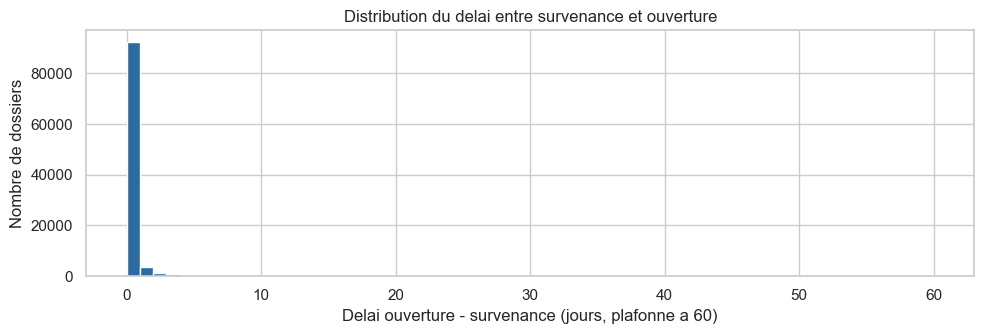

In [18]:
# Visualisation : distribution des delais (ouverture - survenance) en jours
delai_jours = (df_dossier['date.ouverture'] - df_dossier['date.de.survenance']).dt.days
print(delai_jours.describe())

fig, ax = plt.subplots(figsize=(10, 3.5))
delai_jours.clip(upper=60).hist(bins=61, ax=ax, color='#2d6a9f', edgecolor='white')
ax.set_xlabel('Delai ouverture - survenance (jours, plafonne a 60)')
ax.set_ylabel('Nombre de dossiers')
ax.set_title('Distribution du delai entre survenance et ouverture')
plt.tight_layout(); plt.show()


In [19]:
# HEURES D'OUVERTURE INVALIDES
# Le format attendu est HH:MM:SS avec HH <= 24
# Des heures comme 25:00:00 sont des anomalies (debordement au-dela de minuit)

heures_invalides = df_dossier[df_dossier['heure.ouverture'] > '24:00:00']
n_heures_ko = len(heures_invalides)
print(f"Heures invalides (> 24:00:00) : {n_heures_ko} dossiers")

if n_heures_ko > 0:
    print(f"  Valeurs trouvees : {heures_invalides['heure.ouverture'].unique().tolist()}")
    
    # Correction : remplacement par 00:00:00 (minuit)
    # Justification : l'heure est aberrante, on la met a minuit par defaut
    df_dossier['heure.ouverture'] = df_dossier['heure.ouverture'].replace('25:00:00', '00:00:00')
    print(f"  Corrige en '00:00:00'")

    log_anomalie(
        table='dossier', etape='incoherence', variable='heure.ouverture', n=n_heures_ko,
        description=f"{n_heures_ko} heures > 24:00:00 (ex: 25:00:00)",
        retraitement="Remplacees par 00:00:00 (minuit)",
        justification='Heure physiquement impossible (glossaire : HH:MM:SS avec HH dans [0,24])',
    )

# Verification
print(f"Apres correction : {(df_dossier['heure.ouverture'] > '24:00:00').sum()} heures invalides")


Heures invalides (> 24:00:00) : 981 dossiers
  Valeurs trouvees : ['25:00:00']
  Corrige en '00:00:00'
Apres correction : 0 heures invalides


# 2. Table `temps.csv`

**Grain** : 1 ligne = 1 action (création / consultation / modification) sur un dossier.
**Role metier** : porte la variable cible `duree.corrigee` (temps en secondes passé sur le dossier).
**Cle** : composite `(Numero.dossier, Matricule, Date.debut.traitement, heure.debut.traitement)`.

**Points de vigilance du glossaire** :
- `duree.corrigee` est NaN pour les dossiers TEST (~11 % selon glossaire).
- Le matricule `171` (création automatique) est **absent par construction** de cette table.
- Une dossier peut avoir 0 à N lignes ici.

## 2.1 Lecture

In [20]:
df_temps = pd.read_csv(os.path.join(RAW_DIR, 'temps.csv'), encoding='utf-8')
print(f"Dimensions brutes temps.csv : {df_temps.shape}")
df_temps.head()

Dimensions brutes temps.csv : (431598, 5)


,Numero.dossier,Matricule,Date.debut.traitement,heure.debut.traitement,duree.corrigee
0,5465153,1979,2021/07/03,20:04:14,217.0000
1,5465153,1323,2021/07/07,12:29:55,690.0000
2,5465153,1735,2021/07/07,14:31:38,297.0000
3,5465153,1979,2021/07/03,19:42:12,719.0000
4,5465153,706,2021/07/03,18:16:36,44.0000


## 2.2 Info

In [21]:
df_temps.info()
df_temps.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431598 entries, 0 to 431597
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Numero.dossier          431598 non-null  int64  
 1   Matricule               431598 non-null  int64  
 2   Date.debut.traitement   431598 non-null  object 
 3   heure.debut.traitement  431598 non-null  object 
 4   duree.corrigee          384127 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 16.5+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Numero.dossier,431598.0000,NaN,NaN,NaN,6997541.9334,887011.3584,5465153.0000,6229503.0000,6990646.0000,7768250.0000,8536053.0000
Matricule,431598.0000,NaN,NaN,NaN,1039.1724,620.9953,123.0000,519.0000,953.0000,1469.0000,2662.0000
Date.debut.traitement,431598,730,2022/08/16,1469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heure.debut.traitement,431598,63462,09:14:04,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duree.corrigee,384127.0000,NaN,NaN,NaN,312.3104,581.6114,5.0000,52.0000,188.0000,411.0000,253014.0000


In [22]:
# Combien de NaN sur duree.corrigee ? (glossaire annonce ~11 %)
n_total = len(df_temps)
n_na_duree = int(df_temps['duree.corrigee'].isna().sum())
print(f"Lignes totales         : {n_total:,}")
print(f"duree.corrigee = NaN   : {n_na_duree:,} ({100*n_na_duree/n_total:.1f}%)")
print("   -> correspond aux dossiers TEST")

Lignes totales         : 431,598
duree.corrigee = NaN   : 47,471 (11.0%)
   -> correspond aux dossiers TEST


In [23]:
# Dates : format AAAA/MM/JJ
avant_na = df_temps['Date.debut.traitement'].isna().sum()
df_temps['Date.debut.traitement'] = pd.to_datetime(
    df_temps['Date.debut.traitement'], format='%Y/%m/%d', errors='coerce'
)
apres_na = df_temps['Date.debut.traitement'].isna().sum()
n_rejet = int(apres_na - avant_na)
if n_rejet > 0:
    log_anomalie('temps', 'typage', 'Date.debut.traitement', n_rejet,
                 f"{n_rejet} dates non parseables", 'NaT', 'Format AAAA/MM/JJ impose')


df_temps.dtypes

Numero.dossier                     int64
Matricule                          int64
Date.debut.traitement     datetime64[ns]
heure.debut.traitement            object
duree.corrigee                   float64
dtype: object

In [24]:
# --- Validation de heure.debut.traitement ---
# Meme logique que pour dossier.csv : regex stricte HH:MM:SS, bornes h<=24

def heure_valide(x) -> bool:
    """Retourne True si HH:MM:SS est une heure valide."""
    if pd.isna(x):
        return False
    s = str(x).strip()
    if not re.fullmatch(r"\d{2}:\d{2}:\d{2}", s):
        return False
    h, m, sec = map(int, s.split(':'))
    return (m <= 59) and (sec <= 59) and (h <= 24) and not (h == 24 and (m or sec))


masque_heure_ok = df_temps['heure.debut.traitement'].map(heure_valide)
n_heure_ko = int((~masque_heure_ok).sum())

if n_heure_ko > 0:
    valeurs_ko = df_temps.loc[~masque_heure_ok, 'heure.debut.traitement'].value_counts().head(10)
    print(f"Heures invalides dans temps.csv ({n_heure_ko} lignes) :")
    print(valeurs_ko)
    df_temps.loc[~masque_heure_ok, 'heure.debut.traitement'] = np.nan
    log_anomalie('temps', 'encodage', 'heure.debut.traitement', n_heure_ko,
                 f"{n_heure_ko} heures invalides (ex: 25:00:00)",
                 'Mises a NaN',
                 'Regex stricte HH:MM:SS avec bornes h<=24')
else:
    print("Toutes les heures de temps.csv sont valides.")


Toutes les heures de temps.csv sont valides.


## 2.3 Vérification de la délimitation temporelle

In [25]:
# Distribution par annee
print(df_temps['Date.debut.traitement'].dt.year.value_counts(dropna=False).sort_index())

# Filtrage 2021-2022 sur la date de debut de traitement
masque_periode_temps = df_temps['Date.debut.traitement'].between(DATE_DEBUT_PERIODE, DATE_FIN_PERIODE)
n_hors = int((~masque_periode_temps).sum())
if n_hors > 0:
    log_anomalie('temps', 'periode', 'Date.debut.traitement', n_hors,
                 f"{n_hors} actions hors 2021-2022", 'Lignes supprimees',
                 'Perimetre d\'etude glossaire')
df_temps = df_temps.loc[masque_periode_temps].copy()
print(f"Dimensions apres filtrage : {df_temps.shape}")

Date.debut.traitement
2021    192264
2022    239334
Name: count, dtype: int64
Dimensions apres filtrage : (431598, 5)


## 2.4 Doublons

Cle composite `(Numero.dossier, Matricule, Date.debut.traitement, heure.debut.traitement)`.
Dans cette table, un doublon pur est **impossible à arbitrer métier** (deux actions identiques)
et un doublon impur sur la clé (même 4-uplet mais `duree.corrigee` différente) est suspect.

**Règle choisie** : pour chaque doublon pur, on garde une occurrence (`drop_duplicates`).
Pour les impurs, on garde la ligne avec la **plus grande `duree.corrigee`** (hypothèse :
une action plus longue dominera fonctionnellement une saisie partielle).

In [26]:
cle_temps = ['Numero.dossier', 'Matricule', 'Date.debut.traitement', 'heure.debut.traitement']

# Doublons purs
n_avant = len(df_temps)
df_temps = df_temps.drop_duplicates()
n_purs = n_avant - len(df_temps)
if n_purs > 0:
    log_anomalie('temps', 'doublons', '-', n_purs,
                 f"{n_purs} doublons purs", 'drop_duplicates',
                 'Lignes strictement identiques')

# Doublons impurs sur cle composite
masque_dup = df_temps.duplicated(subset=cle_temps, keep=False)
n_impurs = int(masque_dup.sum())
if n_impurs > 0:
    # Garder la ligne avec duree.corrigee max par cle
    df_temps = (
        df_temps.sort_values('duree.corrigee', ascending=False, na_position='last')
                .drop_duplicates(subset=cle_temps, keep='first')
                .sort_index()
    )
    log_anomalie('temps', 'doublons', 'cle_composite', n_impurs,
                 f"{n_impurs} doublons impurs sur (dossier,matricule,date,heure)",
                 'Garder max(duree.corrigee) par cle',
                 'Action plus longue domine saisie partielle')

print(f"Purs supprimes      : {n_purs}")
print(f"Impurs arbitres     : {n_impurs}")
print(f"Dimensions finales  : {df_temps.shape}")

Purs supprimes      : 0
Impurs arbitres     : 0
Dimensions finales  : (431598, 5)


## 2.5 Valeurs manquantes

Dans `temps.csv`, `duree.corrigee = NaN` **n'est pas une erreur** mais l'indicateur métier
du sous-ensemble **TEST** (à prédire). On **ne les impute pas** : on les conserve pour les
identifier en fin de pipeline et les exporter dans `base_test.csv`.

In [27]:
print("Valeurs manquantes dans temps.csv :")
print(df_temps.isna().sum())

n_test = int(df_temps['duree.corrigee'].isna().sum())
print(f"\n{n_test:,} lignes TEST (duree.corrigee NaN) -- conservees pour export separe")

log_anomalie('temps', 'missing', 'duree.corrigee', n_test,
             f"{n_test} NaN = dossiers TEST",
             'Conservees telles quelles',
             'NaN metier : dossiers a predire (glossaire)')

Valeurs manquantes dans temps.csv :
Numero.dossier                0
Matricule                     0
Date.debut.traitement         0
heure.debut.traitement        0
duree.corrigee            47471
dtype: int64

47,471 lignes TEST (duree.corrigee NaN) -- conservees pour export separe


## 2.6 Incohérences métier

1. **Matricule 171** : d'après le glossaire, c'est un automate. Il est censé être **absent**
   de `temps.csv`. On vérifie et on exclut toute ligne éventuelle.
2. **`duree.corrigee` négative ou aberrante** : la durée est positive par nature. On plafonne
   les valeurs extrêmes à la winsorisation P99.9 (préserve la distribution réelle tout en
   neutralisant les outliers techniques).

In [28]:
# 1) Verification matricule 171
n_171 = int((df_temps['Matricule'] == MATRICULE_AUTO).sum())
if n_171 > 0:
    df_temps = df_temps[df_temps['Matricule'] != MATRICULE_AUTO].copy()
    log_anomalie('temps', 'incoherence', 'Matricule', n_171,
                 f"{n_171} lignes avec Matricule 171",
                 'Lignes exclues',
                 'Matricule 171 = automate, absent par construction (glossaire)')
else:
    print("Matricule 171 absent : conforme au glossaire")

# 2) Durees negatives
n_neg = int((df_temps['duree.corrigee'] < 0).sum())
if n_neg > 0:
    df_temps.loc[df_temps['duree.corrigee'] < 0, 'duree.corrigee'] = np.nan
    log_anomalie('temps', 'incoherence', 'duree.corrigee', n_neg,
                 f"{n_neg} durees negatives", 'Mises a NaN',
                 'Une duree est positive par nature')

# 3) Winsorisation P99.9 sur les durees positives
duree_non_na = df_temps['duree.corrigee'].dropna()
p999 = duree_non_na.quantile(0.999)
n_plafonnes = int((df_temps['duree.corrigee'] > p999).sum())
if n_plafonnes > 0:
    df_temps.loc[df_temps['duree.corrigee'] > p999, 'duree.corrigee'] = p999
    log_anomalie('temps', 'incoherence', 'duree.corrigee', n_plafonnes,
                 f"{n_plafonnes} durees > P99.9 ({p999:.0f}s)",
                 f"Plafonnees a P99.9",
                 'Neutraliser outliers sans supprimer de lignes')

print(f"P99.9 de duree.corrigee : {p999:.0f} secondes ({p999/60:.1f} min)")
print(f"Lignes plafonnees       : {n_plafonnes}")

Matricule 171 absent : conforme au glossaire
P99.9 de duree.corrigee : 3688 secondes (61.5 min)
Lignes plafonnees       : 385


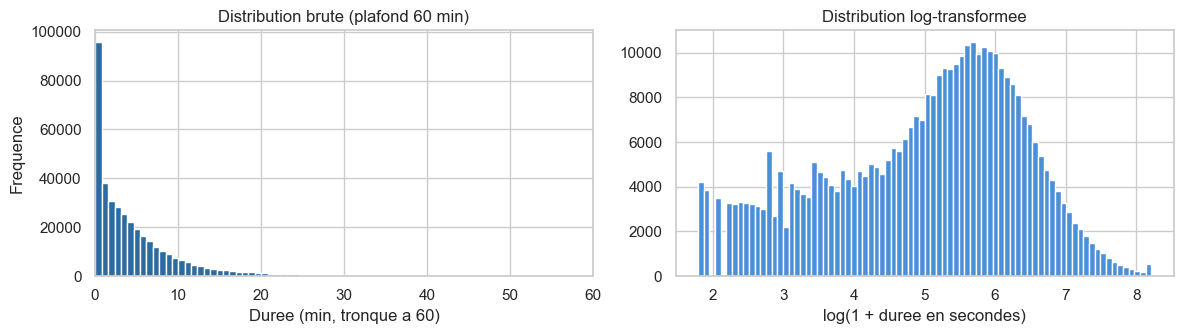

In [29]:
# Visualisation de la distribution de duree.corrigee (echelle log)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

duree_pos = df_temps.loc[df_temps['duree.corrigee'] > 0, 'duree.corrigee']
axes[0].hist(duree_pos / 60, bins=80, color='#2d6a9f', edgecolor='white')
axes[0].set_xlim(0, 60); axes[0].set_xlabel('Duree (min, tronque a 60)')
axes[0].set_title('Distribution brute (plafond 60 min)')
axes[0].set_ylabel('Frequence')

axes[1].hist(np.log1p(duree_pos), bins=80, color='#4a90d9', edgecolor='white')
axes[1].set_xlabel('log(1 + duree en secondes)')
axes[1].set_title('Distribution log-transformee')
plt.tight_layout(); plt.show()

# 3. Table `ressources.csv`

**Grain** : 1 ligne = 1 matricule × 1 jour de présence.
**Role metier** : profile les agents (lieu travail, population CAC/CAS, contrat, expérience).
**Cle** : `(Matricule, Date.presence)`.

**Attention** : `Date.presence` est au format **`JJ/MM/AAAA`**, différent des autres tables.

## 3.1 Lecture

In [30]:
df_ressources_raw = pd.read_csv(os.path.join(RAW_DIR, 'ressources.csv'), encoding='utf-8')
print(f"Dimensions brutes ressources.csv : {df_ressources_raw.shape}")
df_ressources_raw.head()

Dimensions brutes ressources.csv : (389353, 9)


,Matricule,Date.presence,Lieu.travail,Population,Site,Type.de.contrat,Duree.travail,Temps.travail,Experience
0,1243,05/01/2021,TELE,CAS,A,CDI,7.3333,100,5783
1,1243,07/01/2021,TELE,CAS,A,CDI,0.8833,100,5784
2,1243,08/01/2021,TELE,CAS,A,CDI,7.3333,100,5785
3,1243,11/01/2021,TELE,CAS,A,CDI,6.9500,100,5786
4,1243,12/01/2021,TELE,CAS,A,CDI,7.3333,100,5787


## 3.2 Info

In [31]:
df_ressources_raw.info()
print()
df_ressources_raw.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389353 entries, 0 to 389352
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Matricule        389353 non-null  int64  
 1   Date.presence    389353 non-null  object 
 2   Lieu.travail     389353 non-null  object 
 3   Population       389353 non-null  object 
 4   Site             389353 non-null  object 
 5   Type.de.contrat  389353 non-null  object 
 6   Duree.travail    389353 non-null  float64
 7   Temps.travail    389353 non-null  int64  
 8   Experience       389353 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 26.7+ MB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Matricule,389353.0000,NaN,NaN,NaN,1030.2962,591.4966,123.0000,542.0000,967.0000,1450.0000,3192.0000
Date.presence,389353,730,16/08/2022,1076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lieu.travail,389353,2,SITE,196938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Population,389353,2,CAS,353776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Site,389353,2,A,330366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type.de.contrat,389353,3,CDI,246046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duree.travail,389353.0000,NaN,NaN,NaN,6.1451,1.7171,0.0167,5.5000,7.3333,7.3333,23.4167
Temps.travail,389353.0000,NaN,NaN,NaN,72.0830,9.6733,30.0000,70.0000,70.0000,80.0000,100.0000
Experience,389353.0000,NaN,NaN,NaN,1306.5105,1428.0832,0.0000,174.0000,579.0000,2388.0000,6186.0000


In [32]:
# Modalites categorielles
for c in ['Lieu.travail', 'Population', 'Site', 'Type.de.contrat']:
    print(f"--- {c} ---")
    print(df_ressources_raw[c].value_counts(dropna=False))

--- Lieu.travail ---
Lieu.travail
SITE    196938
TELE    192415
Name: count, dtype: int64
--- Population ---
Population
CAS    353776
CAC     35577
Name: count, dtype: int64
--- Site ---
Site
A    330366
B     58987
Name: count, dtype: int64
--- Type.de.contrat ---
Type.de.contrat
CDI    246046
CDD    106118
CDS     37189
Name: count, dtype: int64


In [33]:
df_ressources = df_ressources_raw.copy()

# Date au format JJ/MM/AAAA (spécificité de cette table)
avant_na = df_ressources['Date.presence'].isna().sum()
df_ressources['Date.presence'] = pd.to_datetime(
    df_ressources['Date.presence'], format='%d/%m/%Y', errors='coerce'
)
apres_na = df_ressources['Date.presence'].isna().sum()
n_rejet = int(apres_na - avant_na)
if n_rejet > 0:
    log_anomalie('ressources', 'typage', 'Date.presence', n_rejet,
                 f"{n_rejet} dates non parseables", 'NaT',
                 'Format JJ/MM/AAAA (specifique a ressources.csv)')

df_ressources.dtypes

Matricule                   int64
Date.presence      datetime64[ns]
Lieu.travail               object
Population                 object
Site                       object
Type.de.contrat            object
Duree.travail             float64
Temps.travail               int64
Experience                  int64
dtype: object

In [34]:
# --- Normalisation des tokens manquants dans ressources.csv ---
# Meme logique que pour dossier.csv : les tokens '???', 'NA', 'inconnu', ''
# sont remplaces par NaN pour un traitement uniforme des valeurs manquantes.

cols_cat_res = ['Lieu.travail', 'Population', 'Site', 'Type.de.contrat']

# Nettoyage des espaces
for c in cols_cat_res:
    df_ressources[c] = df_ressources[c].astype('string').str.strip()

# Normalisation tokens -> NaN
df_ressources = normaliser_tokens_manquants(df_ressources, cols_cat_res, 'ressources')

print("Missing apres normalisation tokens :")
print(df_ressources.isna().sum()[df_ressources.isna().sum() > 0])


Missing apres normalisation tokens :
Series([], dtype: int64)


## 3.3 Délimitation temporelle

In [35]:
print(df_ressources['Date.presence'].dt.year.value_counts(dropna=False).sort_index())

masque_periode_res = df_ressources['Date.presence'].between(DATE_DEBUT_PERIODE, DATE_FIN_PERIODE)
n_hors = int((~masque_periode_res).sum())
if n_hors > 0:
    log_anomalie('ressources', 'periode', 'Date.presence', n_hors,
                 f"{n_hors} lignes hors 2021-2022", 'Lignes supprimees',
                 'Perimetre glossaire')
df_ressources = df_ressources.loc[masque_periode_res].copy()
print(f"Dimensions apres filtrage : {df_ressources.shape}")

Date.presence
2021    183093
2022    206260
Name: count, dtype: int64
Dimensions apres filtrage : (389353, 9)


## 3.4 Doublons

Cle composite `(Matricule, Date.presence)`. On ne devrait pas avoir plusieurs lignes pour
un même agent à une même date. Doublons purs → déduplication ; impurs → arbitrage par
première ligne (à ce niveau de granularité, les divergences sont typiquement des erreurs
de saisie sur `Experience`).

In [36]:
cle_res = ['Matricule', 'Date.presence']

n_avant = len(df_ressources)
df_ressources = df_ressources.drop_duplicates()
n_purs = n_avant - len(df_ressources)

masque_dup = df_ressources.duplicated(subset=cle_res, keep=False)
n_impurs = int(masque_dup.sum())
if n_impurs > 0:
    df_ressources = df_ressources.drop_duplicates(subset=cle_res, keep='first')
    log_anomalie('ressources', 'doublons', 'cle_composite', n_impurs,
                 f"{n_impurs} doublons impurs (matricule, date)",
                 'Garder premiere occurrence',
                 'Un agent = 1 enregistrement par jour')
if n_purs > 0:
    log_anomalie('ressources', 'doublons', '-', n_purs,
                 f"{n_purs} doublons purs", 'drop_duplicates',
                 'Lignes strictement identiques')

print(f"Purs : {n_purs} | Impurs : {n_impurs} | Dimensions finales : {df_ressources.shape}")


Purs : 0 | Impurs : 0 | Dimensions finales : (389353, 9)


## 3.5 Valeurs manquantes

In [37]:
print("Valeurs manquantes avant imputation :")
print(df_ressources.isna().sum()[df_ressources.isna().sum() > 0])

Valeurs manquantes avant imputation :
Series([], dtype: int64)


In [38]:
# --- Imputation des valeurs manquantes de ressources.csv ---

def _mode_par_matricule(df, col):
    """Mode d'une colonne pour chaque matricule (profil agent stable dans le temps)."""
    return df.groupby('Matricule')[col].transform(
        lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
    )


# Categorielles : mode par matricule puis mode global
for col in ['Lieu.travail', 'Population', 'Site', 'Type.de.contrat']:
    n_na = int(df_ressources[col].isna().sum())
    if n_na == 0:
        continue
    # Etape 1 : mode par matricule (un agent travaille typiquement au meme site)
    df_ressources[col] = df_ressources[col].fillna(_mode_par_matricule(df_ressources, col))
    # Etape 2 : fallback mode global
    mode_global = df_ressources[col].mode().iloc[0]
    df_ressources[col] = df_ressources[col].fillna(mode_global)
    log_anomalie('ressources', 'missing', col, n_na,
                 f"{n_na} NaN", 'Mode par matricule puis mode global',
                 'Profil agent stable dans le temps')

# Numeriques : mediane (robuste aux outliers)
for col in ['Duree.travail', 'Temps.travail', 'Experience']:
    n_na = int(df_ressources[col].isna().sum())
    if n_na == 0:
        continue
    mediane = df_ressources[col].median()
    df_ressources[col] = df_ressources[col].fillna(mediane)
    log_anomalie('ressources', 'missing', col, n_na,
                 f"{n_na} NaN", f"Impute par mediane ({mediane:.2f})",
                 'Variable numerique : mediane robuste aux outliers')

print("\nValeurs manquantes apres imputation :")
print(df_ressources.isna().sum()[df_ressources.isna().sum() > 0])



Valeurs manquantes apres imputation :
Series([], dtype: int64)


## 3.6 Incohérences métier

### `Duree.travail` — journée théorique 7h20 ≈ 7,33 h

Des valeurs aberrantes peuvent dépasser 12 h (impossible en pratique). On **plafonne à 12 h**.

### `Temps.travail` — doit valoir 100, 80, 50, etc. (pourcentage d'activité)

Les valeurs hors `[0, 100]` sont aberrantes.

In [39]:
# 1) Plafonnement Duree.travail
n_plaf = int((df_ressources['Duree.travail'] > PLAFOND_DUREE_TRAV).sum())
if n_plaf > 0:
    df_ressources['Duree.travail'] = df_ressources['Duree.travail'].clip(upper=PLAFOND_DUREE_TRAV)
    log_anomalie('ressources', 'incoherence', 'Duree.travail', n_plaf,
                 f"{n_plaf} valeurs > {PLAFOND_DUREE_TRAV}h",
                 f"Plafonnees a {PLAFOND_DUREE_TRAV}h",
                 'Journee theorique 7.33h : 12h = plafond metier')

# 2) Temps.travail hors [0, 100]
n_hors = int(((df_ressources['Temps.travail'] < 0) | (df_ressources['Temps.travail'] > 100)).sum())
if n_hors > 0:
    df_ressources['Temps.travail'] = df_ressources['Temps.travail'].clip(lower=0, upper=100)
    log_anomalie('ressources', 'incoherence', 'Temps.travail', n_hors,
                 f"{n_hors} valeurs hors [0,100]",
                 'Clippees a [0,100]',
                 'Pourcentage d\'activite contractuelle')

print(f"Duree.travail plafonnee : {n_plaf}")
print(f"Temps.travail clippe    : {n_hors}")
print(f"\ndescribe(Duree.travail) :\n{df_ressources['Duree.travail'].describe()}")


Duree.travail plafonnee : 5
Temps.travail clippe    : 0

describe(Duree.travail) :
count   389353.0000
mean         6.1450
std          1.7168
min          0.0167
25%          5.5000
50%          7.3333
75%          7.3333
max         12.0000
Name: Duree.travail, dtype: float64


# 4. Fusion des 3 tables

## Stratégie

```
dossier (1 ligne = 1 dossier)
   +-- temps (agrege par dossier)            -> duree_corrigee_totale, nb_interventions, nb_intervenants
   +-- temps x ressources (agrege par dossier) -> exp_moy, prop_tele, pct_cas, pct_cdi, pop_mode, site_mode, ...
```

On garde toutes les lignes de `dossier` (`LEFT JOIN`) pour conserver à la fois les dossiers
d'apprentissage et les dossiers TEST. Les dossiers TEST sont séparés en fin de section.

## 4.1 Agrégation `temps.csv` par dossier


In [40]:
temps_par_dossier = (
    df_temps.groupby('Numero.dossier')
            .agg(
                duree_corrigee_totale = ('duree.corrigee', 'sum'),       # Somme des durees (NaN ignores)
                nb_interventions      = ('duree.corrigee', 'count'),     # Actions avec duree non NaN
                nb_intervenants       = ('Matricule', 'nunique'),        # Intervenants distincts
                temps_moyen_action    = ('duree.corrigee', 'mean'),      # Moyenne par action
                a_lignes_non_predites = ('duree.corrigee', lambda s: int(s.notna().any())),  # 1 si au moins une action non NaN
            )
            .reset_index()
)

# Indicateur : est-ce un dossier TEST ? (aucune action avec duree renseignee)
dossiers_test_ids = (
    df_temps.groupby('Numero.dossier')['duree.corrigee']
            .apply(lambda s: s.isna().all())
)
dossiers_test_ids = dossiers_test_ids[dossiers_test_ids].index.tolist()
print(f"Dossiers TEST detectes (duree.corrigee NaN sur toutes leurs lignes) : {len(dossiers_test_ids):,}")

temps_par_dossier.head()

Dossiers TEST detectes (duree.corrigee NaN sur toutes leurs lignes) : 11,906


,Numero.dossier,duree_corrigee_totale,nb_interventions,nb_intervenants,temps_moyen_action,a_lignes_non_predites
0,5465153,6369.0000,23,13,276.9130,1
1,5465283,88.0000,2,2,44.0000,1
2,5465338,1947.0000,3,2,649.0000,1
3,5465352,3795.0000,7,6,542.1429,1
4,5465369,273.0000,1,1,273.0000,1


## 4.2 Jointure `temps` × `ressources` → features agents

On enrichit chaque ligne de `temps` avec le profil de l'agent ce jour-là.
La jointure se fait sur `(Matricule, date)`. On agrège ensuite par dossier.

In [41]:
# Jointure ligne a ligne : temps x ressources
temps_x_res = df_temps.merge(
    df_ressources,
    left_on=['Matricule', 'Date.debut.traitement'],
    right_on=['Matricule', 'Date.presence'],
    how='left',
)
taux_match = temps_x_res['Lieu.travail'].notna().mean() * 100
print(f"Taux de match (temps x ressources) : {taux_match:.1f}%")


Taux de match (temps x ressources) : 99.5%


In [42]:
def _safe_mode(s: pd.Series):
    """Mode d'une serie, NaN si vide."""
    s = s.dropna()
    return s.mode().iloc[0] if len(s) and not s.mode().empty else np.nan


def _share(s: pd.Series, valeur: str) -> float:
    """Proportion d'une modalite dans une serie."""
    s = s.dropna()
    return (s == valeur).mean() if len(s) else np.nan


features_agents = (
    temps_x_res.groupby('Numero.dossier')
               .agg(
                   exp_moy           = ('Experience', 'mean'),
                   duree_travail_moy = ('Duree.travail', 'mean'),
                   prop_tele         = ('Lieu.travail',    lambda s: _share(s, 'TELE')),
                   pct_cas           = ('Population',      lambda s: _share(s, 'CAS')),
                   pct_cdi           = ('Type.de.contrat', lambda s: _share(s, 'CDI')),
                   pop_mode          = ('Population',      _safe_mode),
                   site_mode         = ('Site',            _safe_mode),
                   type_contrat_mode = ('Type.de.contrat', _safe_mode),
               )
               .reset_index()
)
features_agents.head()

,Numero.dossier,exp_moy,duree_travail_moy,prop_tele,pct_cas,pct_cdi,pop_mode,site_mode,type_contrat_mode
0,5465153,200.2609,6.2022,0.1739,1.0000,0.1739,CAS,A,CDS
1,5465283,222.0000,7.2083,0.5000,0.0000,1.0000,CAC,A,CDI
2,5465338,2371.0000,4.8333,0.0000,1.0000,0.6667,CAS,A,CDI
3,5465352,751.3333,6.5556,0.0000,0.6667,0.3333,CAS,A,CDD
4,5465369,222.0000,7.3333,1.0000,1.0000,0.0000,CAS,A,CDD


## 4.3 Assemblage final

In [43]:
# LEFT JOIN dossier x temps agrege x features agents
base_model = (
    df_dossier
      .merge(temps_par_dossier, left_on=CLE_DOSSIER, right_on='Numero.dossier', how='left')
      .merge(features_agents,   left_on=CLE_DOSSIER, right_on='Numero.dossier', how='left')
)

# Supprimer les colonnes dupliquees de jointure
cols_a_retirer = [c for c in base_model.columns if c.startswith('Numero.dossier')]
base_model = base_model.drop(columns=cols_a_retirer)

print(f"Dimensions base_model : {base_model.shape}")
base_model.head()


Dimensions base_model : (99991, 30)


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,Assistance.ou.Administratif,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties,duree_corrigee_totale,nb_interventions,nb_intervenants,temps_moyen_action,a_lignes_non_predites,exp_moy,duree_travail_moy,prop_tele,pct_cas,pct_cdi,pop_mode,site_mode,type_contrat_mode
0,7494402,C5,F99,2021-02-11,10:38:00,326,Panne mécanique,2021-02-11,Diesel,MCS,Assistance,1,0,0,0,0,0,623.0000,1.0000,1.0000,623.0000,1.0000,1562.0000,3.6667,1.0000,1.0000,1.0000,CAS,A,CDI
1,7569082,C4,F14,2022-07-12,18:40:00,1164,Panne mécanique,2022-07-12,Essence,MCS,Assistance,1,0,0,0,0,0,284.0000,1.0000,1.0000,284.0000,1.0000,2078.0000,7.3333,1.0000,1.0000,1.0000,CAS,A,CDI
2,8111190,C0,F1,2021-01-08,12:32:00,1337,Panne mécanique,2021-01-08,Essence,MCS,Assistance,1,1,0,0,0,0,1849.0000,7.0000,7.0000,264.1429,1.0000,1118.1429,7.4405,0.8571,0.5714,0.4286,CAS,A,CDD
3,5630809,C7,F72,2021-11-08,19:46:00,1322,Panne mécanique,2021-11-08,Essence,MCS,Assistance,1,0,0,0,0,0,988.0000,1.0000,1.0000,988.0000,1.0000,1807.0000,5.5000,1.0000,1.0000,1.0000,CAS,A,CDI
4,8179409,C4,F4,2021-08-11,18:12:00,2306,Panne mécanique,2021-08-11,Essence,Higgins,Assistance,1,0,0,0,0,0,1133.0000,3.0000,2.0000,377.6667,1.0000,25.0000,7.3333,0.0000,0.6667,0.0000,CAS,A,CDS


In [44]:
# Imputation residuelle : dossiers sans lignes dans temps.csv
# (matricule 171 = creation automatique, jamais de temps humain)
print("NA residuels :")
print(base_model.isna().sum()[base_model.isna().sum() > 0])


NA residuels :
duree_corrigee_totale     2205
nb_interventions          2205
nb_intervenants           2205
temps_moyen_action       13041
a_lignes_non_predites     2205
exp_moy                   2304
duree_travail_moy         2304
prop_tele                 2304
pct_cas                   2304
pct_cdi                   2304
pop_mode                  2304
site_mode                 2304
type_contrat_mode         2304
dtype: int64


In [45]:
# Compteurs : 0 action si aucune ligne temps
for c in ['duree_corrigee_totale', 'nb_interventions', 'nb_intervenants', 'temps_moyen_action']:
    n_na = int(base_model[c].isna().sum())
    if n_na > 0:
        base_model[c] = base_model[c].fillna(0)
        log_anomalie('global', 'fusion', c, n_na,
                     f"{n_na} dossiers sans lignes dans temps.csv",
                     'Impute 0',
                     'Dossier cree automatiquement (matricule 171) : 0 action humaine')

# Features agents : mediane pour numeriques, mode pour categorielles
for c in ['exp_moy', 'duree_travail_moy', 'prop_tele', 'pct_cas', 'pct_cdi']:
    n_na = int(base_model[c].isna().sum())
    if n_na > 0:
        med = base_model[c].median()
        base_model[c] = base_model[c].fillna(med)
        log_anomalie('global', 'fusion', c, n_na,
                     f"{n_na} NaN", f"Impute par mediane ({med:.3f})",
                     'Dossier sans matching agents (creation auto)')

for c in ['pop_mode', 'site_mode', 'type_contrat_mode']:
    n_na = int(base_model[c].isna().sum())
    if n_na > 0:
        mode_val = base_model[c].mode().iloc[0]
        base_model[c] = base_model[c].fillna(mode_val)
        log_anomalie('global', 'fusion', c, n_na,
                     f"{n_na} NaN", f"Impute par mode global ('{mode_val}')",
                     'Dossier sans matching agents')

# Gerer aussi 'a_lignes_non_predites' : si absent, 0 (pas de lignes temps -> TEST implicite)
if 'a_lignes_non_predites' in base_model.columns:
    base_model['a_lignes_non_predites'] = base_model['a_lignes_non_predites'].fillna(0).astype('int8')

print("\nNA residuels apres imputation :")
print(base_model.isna().sum()[base_model.isna().sum() > 0])



NA residuels apres imputation :
Series([], dtype: int64)


# 5. Séparation Train / Test Dossiers

Selon le glossaire, **~11 %** des dossiers ont `duree.corrigee` NaN sur toutes leurs
actions dans `temps.csv` : ce sont les **dossiers TEST** à prédire. Deux critères concordants
identifient un dossier TEST :

1. `duree_corrigee_totale == 0` (somme des durées vide car tout NaN),
2. `a_lignes_non_predites == 0` (aucune action `temps` avec une durée renseignée).

Un dossier sans aucune ligne dans `temps.csv` (matricule 171 automate) est aussi considéré
comme TEST puisqu'on n'a rien à prédire pour lui : il ne fait de toute façon pas partie du
signal d'apprentissage.

**On retire les dossiers TEST de `base_model` et on les sauvegarde à part dans `base_test.csv`.**

In [46]:
# Masque TEST : aucune action avec duree renseignee ET duree totale = 0
masque_test = (base_model['a_lignes_non_predites'] == 0)
base_test = base_model.loc[masque_test].copy()
base_train = base_model.loc[~masque_test].copy()

n_total = len(base_model)
n_test  = len(base_test)
n_train = len(base_train)
print(f"Total        : {n_total:,}")
print(f"Train        : {n_train:,} ({100*n_train/n_total:.1f}%)")
print(f"Test         : {n_test:,}  ({100*n_test/n_total:.1f}%)")
print(f"Glossaire    : ~89 % apprentissage / ~11 % test")

log_anomalie('global', 'split', 'duree_corrigee_totale', n_test,
             f"{n_test} dossiers TEST",
             'Exportes dans base_test.csv',
             'Glossaire : 89/11 train/test ; TEST = duree.corrigee NaN')

Total        : 99,991
Train        : 86,950 (87.0%)
Test         : 13,041  (13.0%)
Glossaire    : ~89 % apprentissage / ~11 % test


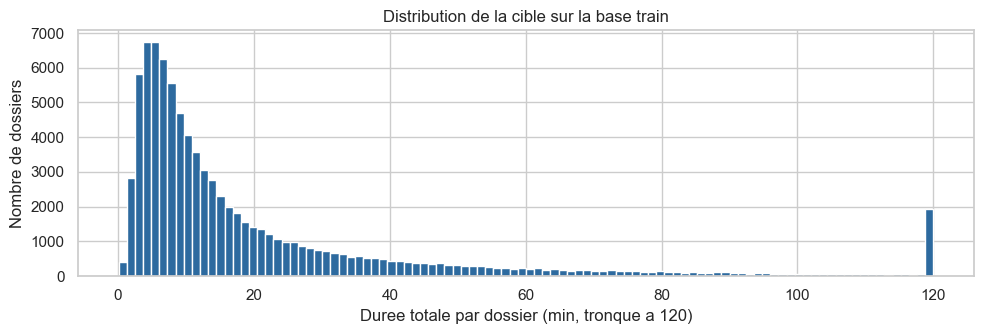

count   86950.0000
mean     1338.1838
std      2013.3482
min         5.0000
25%       356.0000
50%       659.0000
75%      1442.0000
max     58720.0000
Name: duree_corrigee_totale, dtype: float64


In [47]:
# Verification visuelle de la cible sur train
fig, ax = plt.subplots(figsize=(10, 3.5))
(base_train['duree_corrigee_totale'] / 60).clip(upper=120).hist(
    bins=100, ax=ax, color='#2d6a9f', edgecolor='white'
)
ax.set_xlabel('Duree totale par dossier (min, tronque a 120)')
ax.set_ylabel('Nombre de dossiers')
ax.set_title('Distribution de la cible sur la base train')
plt.tight_layout(); plt.show()

print(base_train['duree_corrigee_totale'].describe())

# 6. Tableau récapitulatif des anomalies, retraitements et justifications

Tous les retraitements appliqués par ce notebook ont été tracés via `log_anomalie(...)`.
On les consolide ici en un DataFrame exporté en CSV pour audit et traçabilité.

In [48]:
anomalies_df = pd.DataFrame(ANOMALIES)
# Ordre lisible
ordre_tables = ['dossier', 'temps', 'ressources', 'global']
anomalies_df['table'] = pd.Categorical(anomalies_df['table'], categories=ordre_tables, ordered=True)
anomalies_df = anomalies_df.sort_values(['table', 'etape', 'variable']).reset_index(drop=True)

print(f"Nombre total de retraitements traces : {len(anomalies_df)}")
anomalies_df

Nombre total de retraitements traces : 31


,table,etape,variable,lignes_impactees,description,retraitement,justification
0,dossier,doublons,Numero_dossier_ID,782,782 lignes impures reparties sur 391 dossiers,Ligne de reference + arbitrage colonne par col...,Impossible de supprimer car meme Numero_dossie...
1,dossier,doublons,Numero_dossier_ID,842,842 doublons purs,drop_duplicates (garder 1 occurrence),Lignes strictement identiques : aucune perte d...
2,dossier,encodage,Assistance.ou.Administratif,9999,"9999 valeurs parmi ['', '???', 'INCONNU', 'Inc...",Remplacees par NaN,Tokens d'absence detectes par inspection visuelle
3,dossier,encodage,Formule,5000,"5000 valeurs parmi ['', '???', 'INCONNU', 'Inc...",Remplacees par NaN,Tokens d'absence detectes par inspection visuelle
4,dossier,encodage,Type.d.energie,500,"500 valeurs parmi ['', '???', 'INCONNU', 'Inco...",Remplacees par NaN,Tokens d'absence detectes par inspection visuelle
5,dossier,incoherence,date.de.survenance,981,981 NaT,Impute par date.ouverture,Borne inferieure metier : survenance <= ouverture
6,dossier,incoherence,date.de.survenance,7,7 cas survenance > ouverture,Remplace par date.ouverture,Impossibilite metier : sinistre apres ouverture
7,dossier,incoherence,heure.ouverture,981,981 heures > 24:00:00 (ex: 25:00:00),Remplacees par 00:00:00 (minuit),Heure physiquement impossible (glossaire : HH:...
8,dossier,missing,Assistance.ou.Administratif,9764,9764 NaN,Impute par mode global ('Assistance'),"Binaire, mode >80%"
9,dossier,missing,Cause.intervention,977,977 NaN,Impute 'Non renseignee',Pas de proxy fiable : creer une modalite expli...


In [49]:
# Synthese par table
print("--- Nombre de retraitements par table ---")
print(anomalies_df['table'].value_counts().sort_index())
print()
print("--- Nombre de lignes impactees cumulees par table ---")
print(anomalies_df.groupby('table', observed=True)['lignes_impactees'].sum())

--- Nombre de retraitements par table ---
table
dossier       15
temps          2
ressources     1
global        13
Name: count, dtype: int64

--- Nombre de lignes impactees cumulees par table ---
table
dossier       38128
temps         47856
ressources        5
global        51129
Name: lignes_impactees, dtype: int64


In [50]:
# Export du tableau d'anomalies
anomalies_df.to_csv(ANOMALIES_PATH, index=False, encoding='utf-8')
print(f"Tableau d'anomalies exporte : {ANOMALIES_PATH}")

Tableau d'anomalies exporte : ../data/processed/anomalies_retraitements.csv


# 7. Export final

On exporte :

- `base_model.csv` — base d'**apprentissage** (dossiers avec `duree_corrigee_totale > 0`)
- `base_test.csv` — base de **test** (dossiers à prédire, `duree.corrigee` NaN)
- `anomalies_retraitements.csv` — tableau de traçabilité (déjà exporté en section 6)

In [51]:
# Feature engineering temporel sur la base train (utile pour les notebooks downstream)
for base in (base_train, base_test):
    base['annee']        = base['date.ouverture'].dt.year
    base['mois']         = base['date.ouverture'].dt.month
    base['jour_semaine'] = base['date.ouverture'].dt.day_name()
    base['delai_jours']  = (
        (base['date.ouverture'] - base['date.de.survenance']).dt.days.clip(lower=0)
    )
    base['nb_services']  = base[[c for c in base.columns if c.startswith('TOP.')]].sum(axis=1)

# Colonnes finales communes
cols_out = [
    CLE_DOSSIER, 'Client', 'Formule', 'date.ouverture', 'heure.ouverture',
    'Matricule.de.traitement', 'Cause.intervention', 'date.de.survenance',
    'Type.d.energie', 'Outil.d.assistance', 'Assistance.ou.Administratif',
    'TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup', 'TOP.Autres.Garanties',
    'annee', 'mois', 'jour_semaine', 'delai_jours', 'nb_services',
    'duree_corrigee_totale', 'nb_interventions', 'nb_intervenants', 'temps_moyen_action',
    'exp_moy', 'duree_travail_moy', 'prop_tele', 'pct_cas', 'pct_cdi',
    'pop_mode', 'site_mode', 'type_contrat_mode',
]
cols_out = [c for c in cols_out if c in base_train.columns]

base_train[cols_out].to_csv(OUT_PATH, index=False, encoding='utf-8')
base_test[cols_out].to_csv(TEST_PATH, index=False, encoding='utf-8')

print(f"Exporte : {OUT_PATH}  ({base_train.shape})")
print(f"Exporte : {TEST_PATH}  ({base_test.shape})")

Exporte : ../data/processed/base_model.csv  ((86950, 35))
Exporte : ../data/processed/base_test.csv  ((13041, 35))
